In [18]:
## Importing Libraries

from __future__ import print_function
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../Data-processed/crop_recommendation.csv")

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,94,39,41,20.879744,82.002744,6.502985,202.935536,rice
1,93,58,39,21.770462,80.319644,7.038096,226.655537,rice
2,72,47,39,23.004459,82.320763,7.840207,263.964248,rice
3,70,46,35,26.491096,80.158363,6.980401,242.864034,rice
4,77,45,37,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,105,16,28,26.774637,66.413269,6.780064,177.774507,coffee
2196,86,18,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,91,26,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,86,25,26,26.272418,52.127394,6.758793,127.175293,coffee
2199,84,34,34,23.603016,60.396475,6.779833,140.937041,coffee


In [6]:
df.size

17600

In [7]:
df.shape

(2200, 8)

In [9]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [10]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [11]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [13]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

<Axes: >

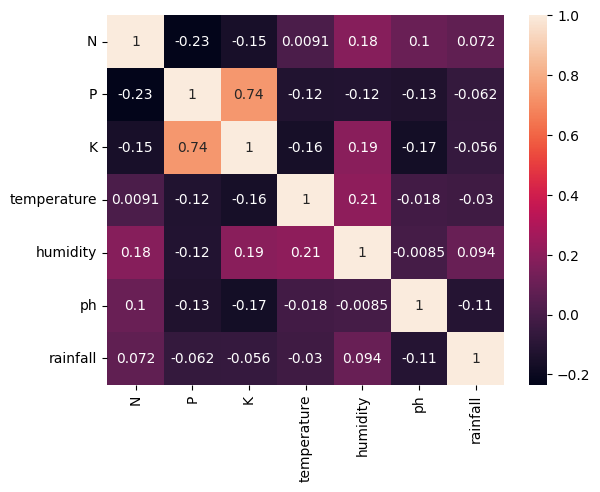

In [14]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [15]:
features = df[['N','P','K','temperature','humidity','ph','rainfall']]
target = df['label']

labels = df['label']

In [16]:
# Initialzing empty lists to append all model's name and corresponding name
acc = []
model = []

In [17]:
# splitting into train and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=2)

Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier

DecisionTree = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)
DecisionTree.fit(X_train,y_train)

predicted_values = DecisionTree.predict(X_test)
X = accuracy_score(y_test,predicted_values)
acc.append(X)
model.append('Decision Tree')
print("DecisionTree's Accuracy is: ",X*100)

print(classification_report(y_test,predicted_values))
print(confusion_matrix(y_test,predicted_values))

DecisionTree's Accuracy is:  91.13636363636364
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.64      1.00      0.78        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      0.95      0.98        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       1.00      0.21      0.35        28
 kidneybeans       1.00      0.79      0.88        14
      lentil       0.88      1.00      0.94        23
       maize       0.83      0.95      0.89        21
       mango       1.00      0.96      0.98        26
   mothbeans       1.00      0.42      0.59        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00 

In [20]:
from sklearn.model_selection import cross_val_score

In [21]:
score = cross_val_score(DecisionTree,features,target,cv=5)

In [22]:
score

array([0.91590909, 0.90909091, 0.925     , 0.92272727, 0.93636364])

In [23]:
import pickle
DT_pkl_filename = '../models/DecisionTree.pkl'
DT_Model_pkl = open(DT_pkl_filename,'wb')
pickle.dump(DecisionTree,DT_Model_pkl)
DT_Model_pkl.close()

Guassian Naive Bayes

In [24]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(X_train,y_train)

predicted_values = NaiveBayes.predict(X_test)
X = accuracy_score(y_test,predicted_values)
acc.append(X)
model.append("Naive Bayes")
print("Naive Bayes's Accuracy is: ",X*100)
print(classification_report(y_test,predicted_values))
print(confusion_matrix(y_test,predicted_values))


Naive Bayes's Accuracy is:  98.63636363636363
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.94      1.00      0.97        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.88      1.00      0.93        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.96      1.00      0.98        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.89      0.94        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00  

In [25]:
score = cross_val_score(NaiveBayes,features,target,cv=5)
score

array([0.99772727, 0.99772727, 0.99318182, 0.98636364, 0.99090909])

In [26]:
import pickle
NB_pkl_filename = "../models/NBClassifier.pkl"
NB_Model_pkl = open(NB_pkl_filename,'wb')
pickle.dump(NaiveBayes,NB_Model_pkl)
NB_Model_pkl.close()

Support Vector Machine (SVM)

In [29]:
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
X_train_norm = norm.fit_transform(X_train)
X_test_norm = norm.transform(X_test)
SVM = SVC(kernel='poly',degree=3,C=1)
SVM.fit(X_train_norm,y_train)
predicted_values = SVM.predict(X_test_norm)
x = accuracy_score(y_test,predicted_values)
acc.append(x)
model.append("SVM")
print("SVM's Accuracy is: ",x*100)
print(classification_report(y_test,predicted_values))
print(confusion_matrix(y_test,predicted_values))

SVM's Accuracy is:  97.95454545454545
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.94      1.00      0.97        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.86      0.89      0.88        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.96      1.00      0.98        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.89      0.94        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00

In [30]:
score = cross_val_score(SVM,features,target,cv=5)
score

array([0.97272727, 0.97727273, 0.99090909, 0.97727273, 0.97954545])

In [31]:
import pickle
SVM_pkl_filename = '../models/SVMClassifier.pkl'
SVM_Model_pkl = open(SVM_pkl_filename,'wb')
pickle.dump(SVM,SVM_Model_pkl)
SVM_Model_pkl.close()

Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

LogReg = LogisticRegression(random_state=2)
LogReg.fit(X_train,y_train)

predicted_values = LogReg.predict(X_test)
x = accuracy_score(y_test,predicted_values)
acc.append(x)
model.append('Logistic Regression')
print("Logistic Regression's Accuracy is: ",x*100)
print(classification_report(y_test,predicted_values))
print(confusion_matrix(y_test,predicted_values))

Logistic Regression's Accuracy is:  96.13636363636363
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.80      1.00      0.89        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      0.95      0.98        21
      coffee       1.00      1.00      1.00        22
      cotton       0.95      0.95      0.95        20
      grapes       1.00      1.00      1.00        18
        jute       0.86      0.89      0.88        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.92      0.96      0.94        23
       maize       0.95      0.95      0.95        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.79      0.88        19
    mungbean       1.00      0.96      0.98        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00    

In [33]:
score = cross_val_score(LogReg,features,target,cv=5)
score

array([0.94545455, 0.95681818, 0.96818182, 0.95227273, 0.95      ])

In [35]:
import pickle
LR_pkl_filename = '../models/LogisticRegression.pkl'
LR_Model_pkl = open(DT_pkl_filename, 'wb')
pickle.dump(LogReg, LR_Model_pkl)
LR_Model_pkl.close()


Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(X_train,y_train)

predicted_values = RF.predict(X_test)

x = accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('RF')
print("RF's Accuracy is: ", x)

print(classification_report(y_test,predicted_values))
print(confusion_matrix(y_test,predicted_values))

RF's Accuracy is:  0.9863636363636363
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.94      1.00      0.97        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.90      0.96      0.93        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.96      1.00      0.98        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.89      0.94        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00

In [37]:
score = cross_val_score(LogReg,features,target,cv=5)
score

array([0.94545455, 0.95681818, 0.96818182, 0.95227273, 0.95      ])

In [39]:
import pickle
RF_pkl_filename = '../models/RandomForest.pkl'
RF_Model_pkl = open(RF_pkl_filename, 'wb')
pickle.dump(RF, RF_Model_pkl)
RF_Model_pkl.close()


XGBoost